In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, make_scorer, f1_score, roc_curve, auc
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
import optuna

# Display all float values in Pandas with 2 decimal places
pd.set_option('display.float_format', lambda x: '{:.2f}'.format(x))

# Display NumPy numbers without scientific notation (e.g., 0.000123 instead of 1.23e-04)
np.set_printoptions(suppress=True)

### Load Data 

In [23]:
df_customers = pd.read_csv('../customers.csv')
df_loans = pd.read_csv('../loans.csv')
df_bureau = pd.read_csv('../bureau_data.csv')

In [24]:
df_customers.shape, df_loans.shape, df_bureau.shape

((50000, 12), (50000, 15), (50000, 8))

Now let's merge them on cust_id column to create one single Dataframe.

In [25]:
df = pd.merge(df_customers, df_loans, on='cust_id')
df = pd.merge(df, df_bureau, on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10


Our target column is default which has boolean value, let's convert it into integer(as 0 & 1)

In [26]:
df['default'] = df['default'].astype(int)
df['default'].value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

As you can see there is very high class imbalance. We need to handle that as well.

We will do train test split now, Why? In most of previous projects we did data splitting just before training our model.Then Why here at first? That's because of data leakage concern.

If we do EDA or feature engineering tranformations on complete data, then my train data will have influence of test data. Which will influence my model performance overall and upon seeing new data my model won't give good performance. This is called train test contamination. Which leads to data leakage.

In [27]:
# Selecting feature and target variable to do split
X = df.drop('default', axis=1)
y = df['default']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

In [28]:
# Now for EDA and FE let's Concat feature and target variable again.
df_train = pd.concat([X_train,y_train], axis = 1)
df_test = pd.concat([X_test,y_test], axis = 1)

df_train.shape , df_test.shape

((37500, 33), (12500, 33))

In [29]:
df_train.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,2020-06-18,2020-07-07,3,0,76,0,0,8,87,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,2020-11-12,2020-12-07,1,2,60,0,0,1,71,0


### Data Cleaning

In [30]:
# Handlling Null Values
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

Let's fill these null values with mode.

In [31]:
# Get Unique values
df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [32]:
residence_mode = df_train.residence_type.mode()[0]
residence_mode

'Owned'

In [33]:
# Fill both train and test with the mode value (Which is 'owned' for both)
df_train['residence_type'] = df_train['residence_type'].fillna(residence_mode)
df_test['residence_type'] = df_test['residence_type'].fillna(residence_mode)

df_train.residence_type.unique()

array(['Owned', 'Mortgage', 'Rented'], dtype=object)

In [34]:
# Handle duplicate values if present
df_train.duplicated().sum()

0

In [35]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37500 entries, 12746 to 37784
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cust_id                      37500 non-null  object 
 1   age                          37500 non-null  int64  
 2   gender                       37500 non-null  object 
 3   marital_status               37500 non-null  object 
 4   employment_status            37500 non-null  object 
 5   income                       37500 non-null  int64  
 6   number_of_dependants         37500 non-null  int64  
 7   residence_type               37500 non-null  object 
 8   years_at_current_address     37500 non-null  int64  
 9   city                         37500 non-null  object 
 10  state                        37500 non-null  object 
 11  zipcode                      37500 non-null  int64  
 12  loan_id                      37500 non-null  object 
 13  loan_purpose     

In [36]:
# Seperating numeric and categorical columns
numerical_columns = ['age', 'income', 'number_of_dependants', 'years_at_current_address','sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio']

categorical_columns = ['gender', 'marital_status', 'employment_status', 'residence_type',
       'city', 'state', 'loan_purpose', 'loan_type','zipcode']

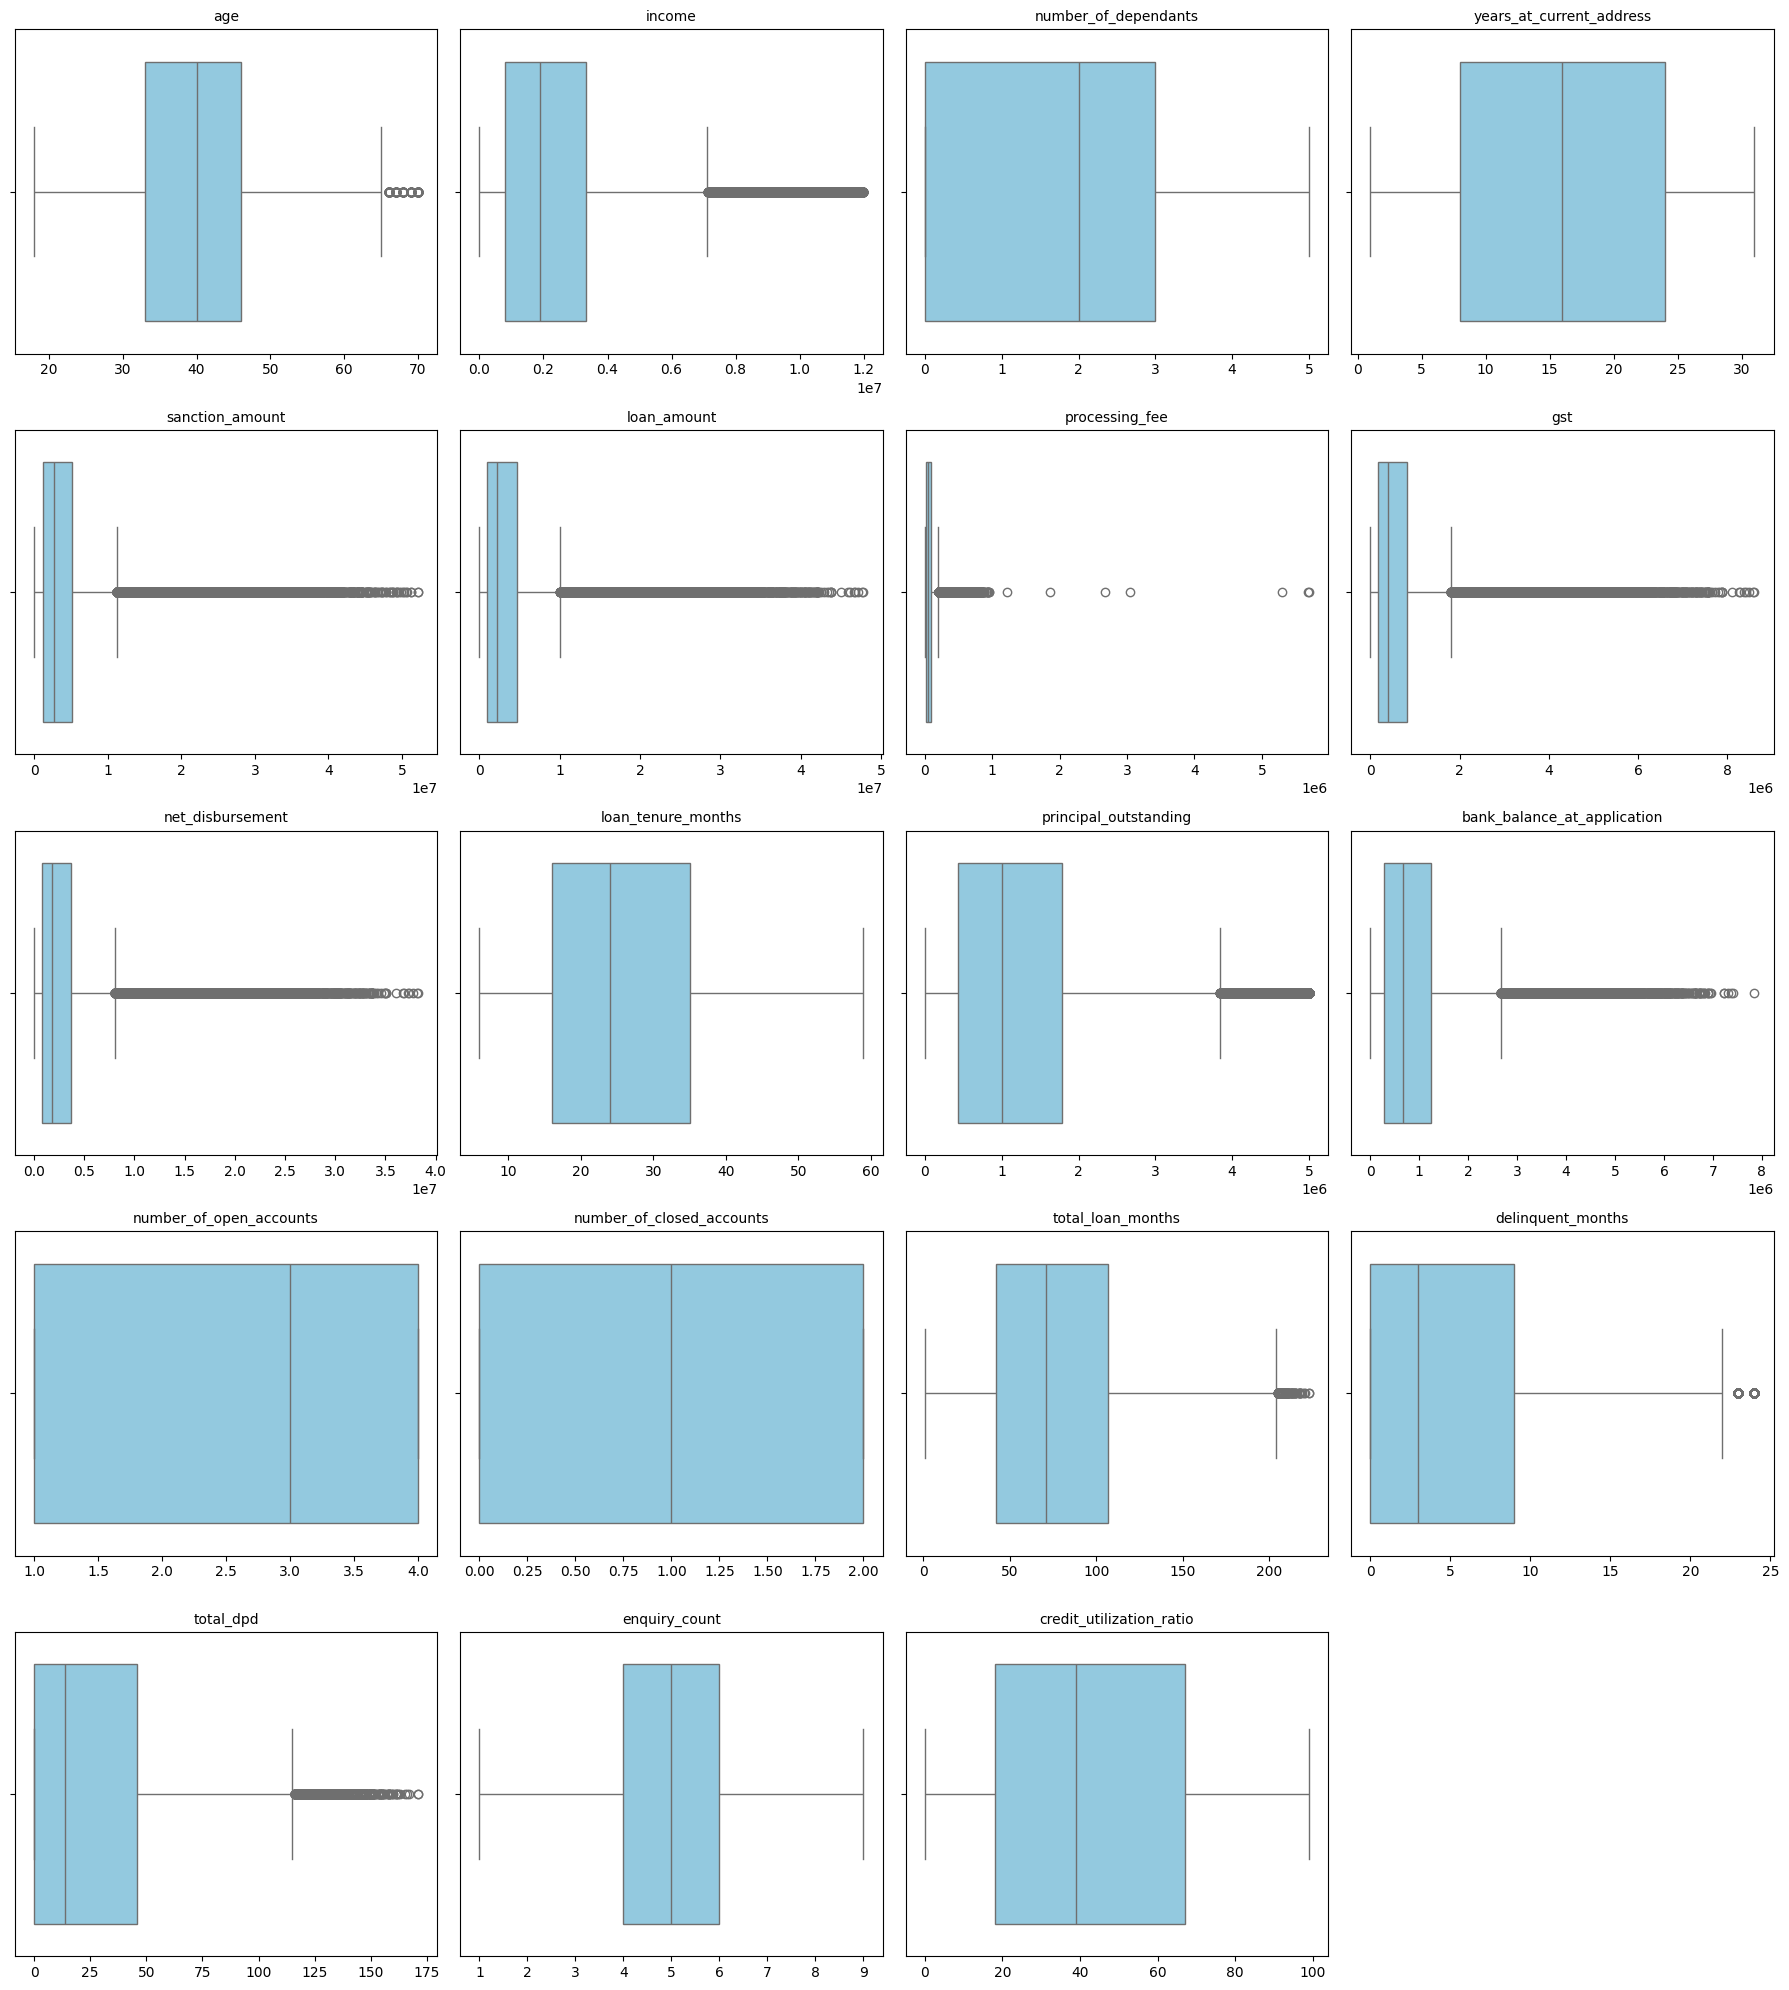

In [37]:
# Outlier Treatment

# Let's first try visuallizing them using boxplot.
# Grid size
n_cols = 4  # Number of plots per row
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.boxplot(x=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

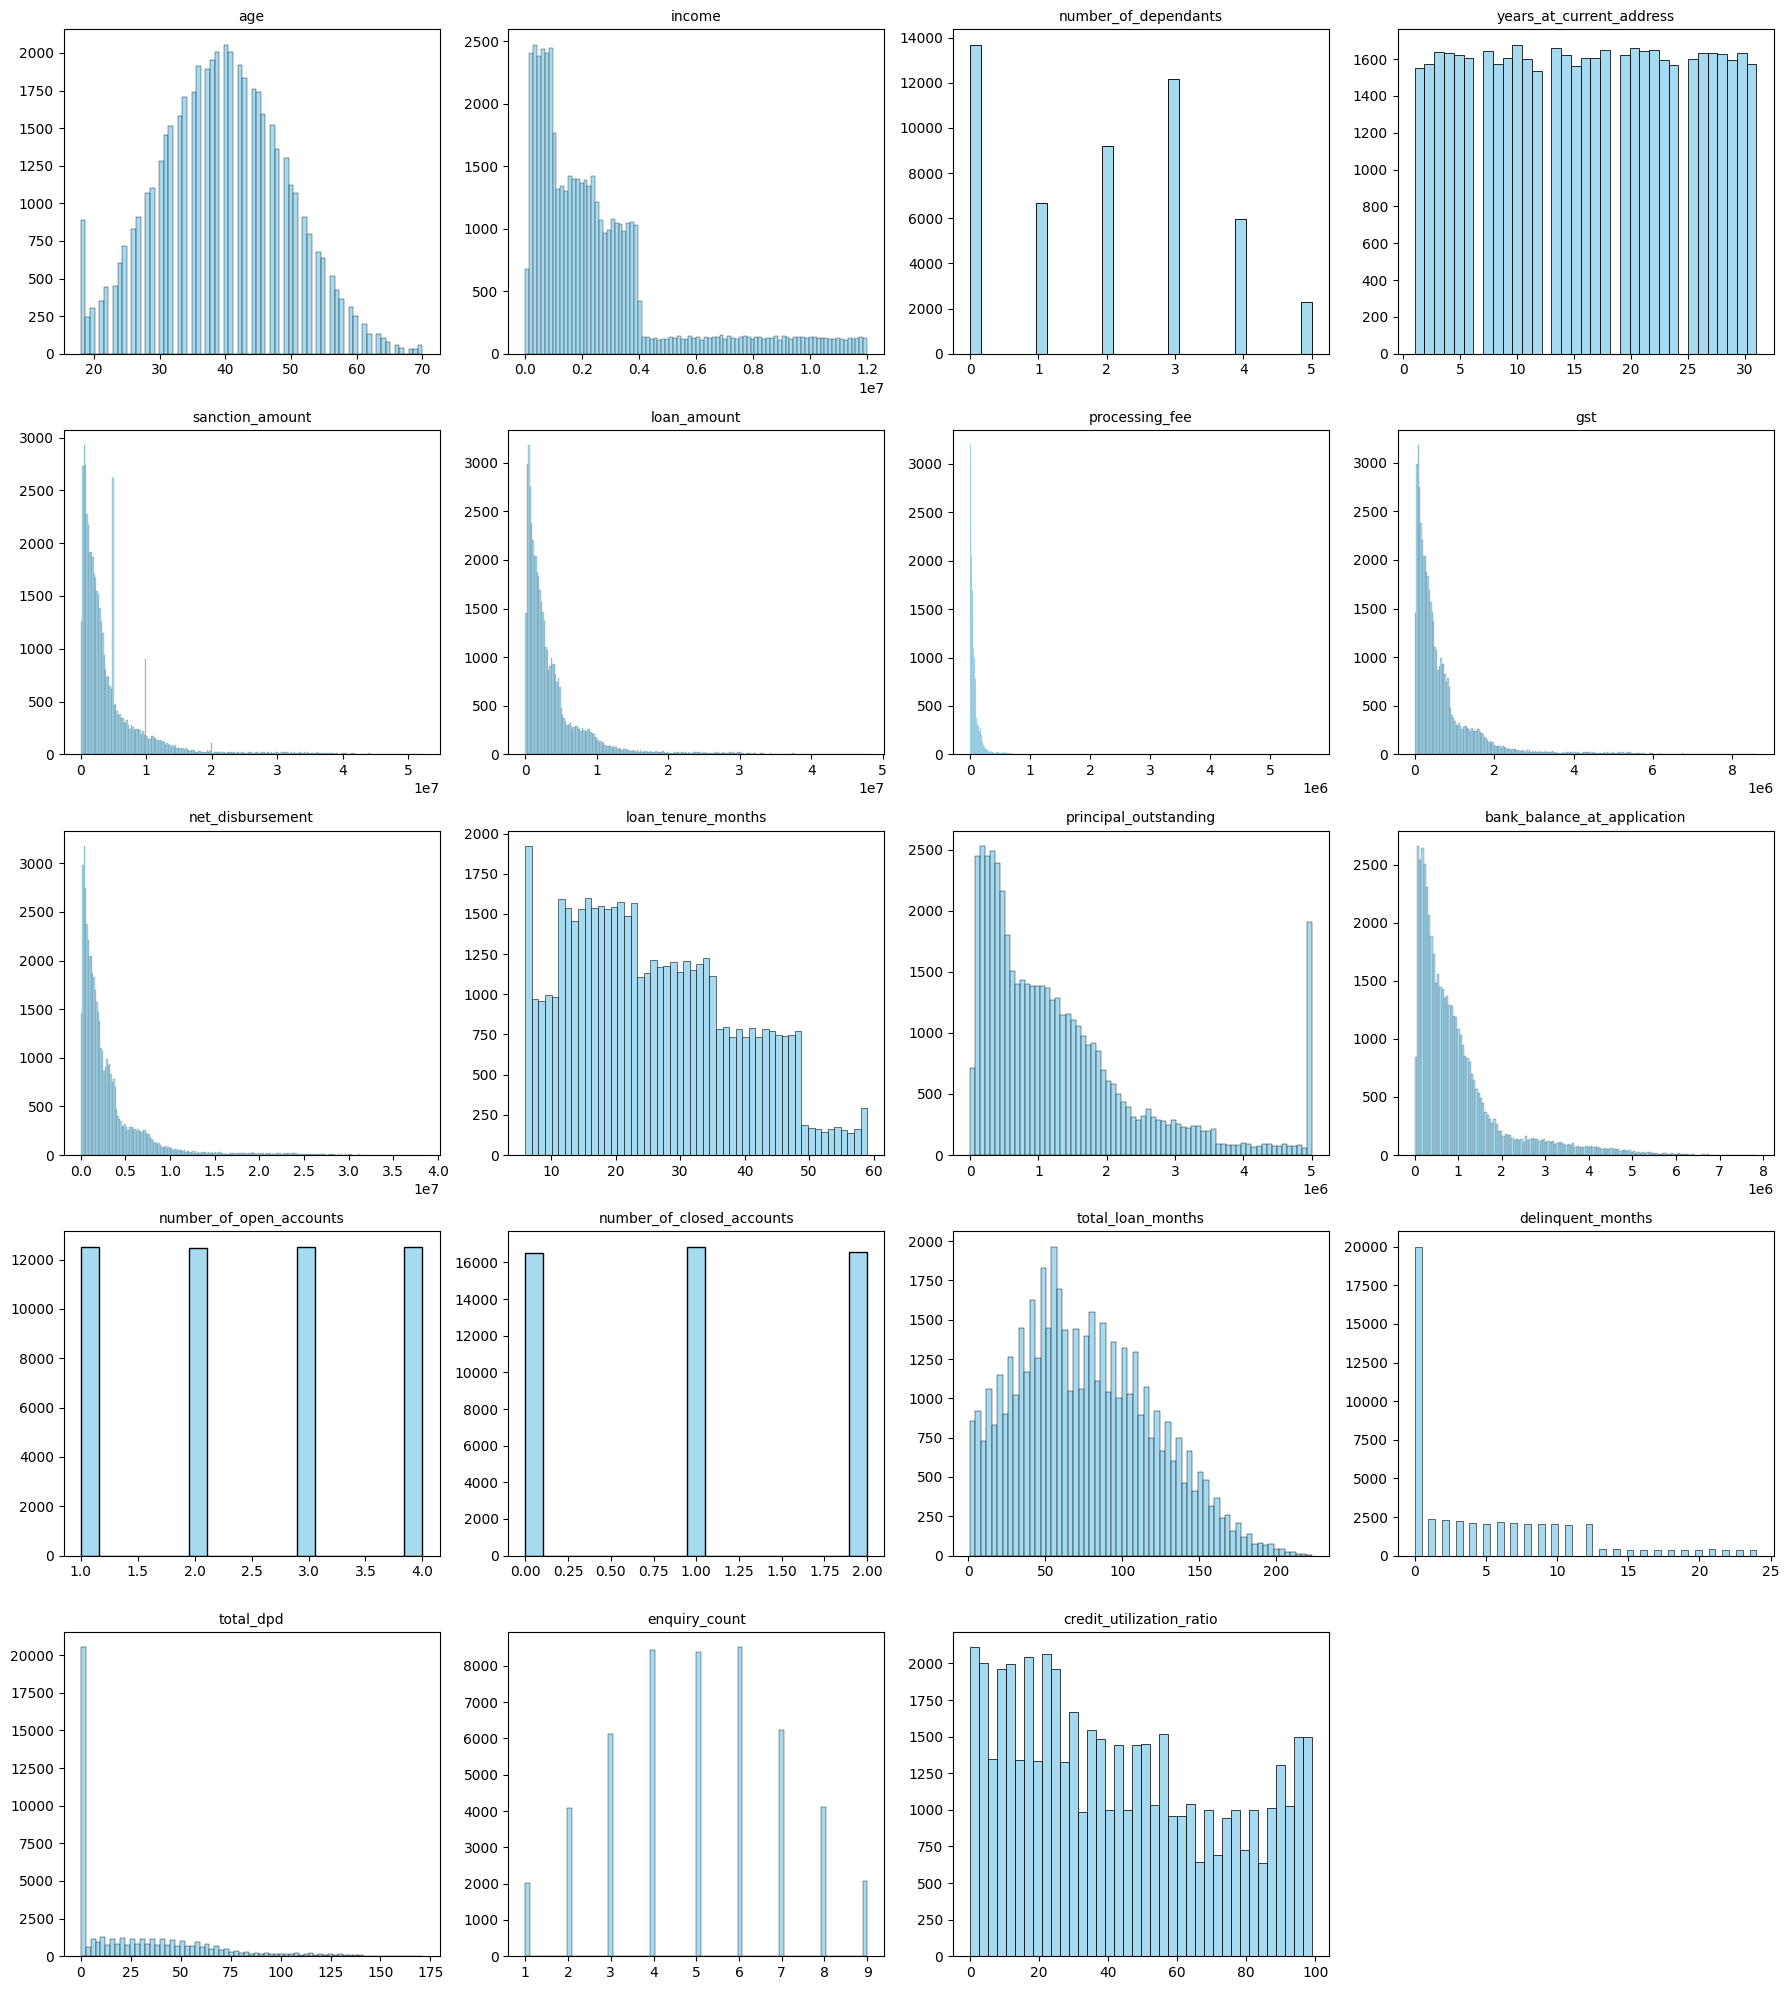

In [38]:
# Let's plot histograms now for all the numeric columns

# Grid size
n_cols = 4  # Number of plots per row
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.histplot(x=df[col], ax=axes[i], color="skyblue")
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Here we can see a lot of outliers in processing fee column, Let's analyze that column more closely.

In [39]:
df_train['processing_fee'].describe()

count     37500.00
mean      80290.68
std      113128.14
min           0.00
25%       19220.00
50%       44600.00
75%       92420.00
max     5293543.52
Name: processing_fee, dtype: float64

Max processing fee is 52 lacs which is possible but for what's loan amount it is let's check.

In [40]:
df_train[df_train['processing_fee'] == df_train['processing_fee'].max()][['loan_amount','processing_fee']]

,loan_amount,processing_fee
9898,3626000,5293543.52


For 36 lacs loan amount the processing fee of 52 lacs is impossible, In real bussiness scenario processing fee will always be lower than actual loan amount, and mostly it is 3% of the loan amount. So with that logic let's find out outliers and treat them.

In [41]:
df_train[(df_train['processing_fee']/df_train['loan_amount']) > 0.03][['loan_amount','processing_fee']].shape

(5, 2)

So these 5 records are actual outliers let's remove them.

In [42]:
df_train.shape

(37500, 33)

In [43]:
df_train[(df_train['processing_fee']/df_train['loan_amount']) <= 0.03].shape

(37488, 33)

Now the difference is 12, but we only have 5 records which have > 3% fee, then how it this possible? So the actual reason is that other 7 records have both processing fee and loan amount zero and zero/zero becomes undefined coz divison is not possible therefore it's not getting counted in either conditions. Now these are also outliers/false records. So we can just remove all 12.

In [44]:
df_train = df_train[(df_train['processing_fee']/df_train['loan_amount']) <= 0.03]
df_train.shape

(37488, 33)

In [45]:
# Apply same step on test data
df_test = df_test[(df_test['processing_fee']/df_test['loan_amount']) <= 0.03]
df_test.shape

(12497, 33)

In [46]:
# Let's analyze categorical columns now by printing unique values of all columns
for col in categorical_columns:
    print(f"{col}:{df_train[col].unique()}")

gender:['M' 'F']
marital_status:['Married' 'Single']
employment_status:['Self-Employed' 'Salaried']
residence_type:['Owned' 'Mortgage' 'Rented']
city:['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state:['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
loan_purpose:['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type:['Secured' 'Unsecured']
zipcode:[500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]


Here loan purpose column has some false data entering let's replace personaal with personal.

In [47]:
df_train.loan_purpose = df_train.loan_purpose.replace('Personaal','Personal')
df_test.loan_purpose = df_test.loan_purpose.replace('Personaal','Personal') # Same with test data
df_train.loan_purpose.unique()

array(['Home', 'Education', 'Personal', 'Auto'], dtype=object)

## Exploratory Data Analysis (EDA)

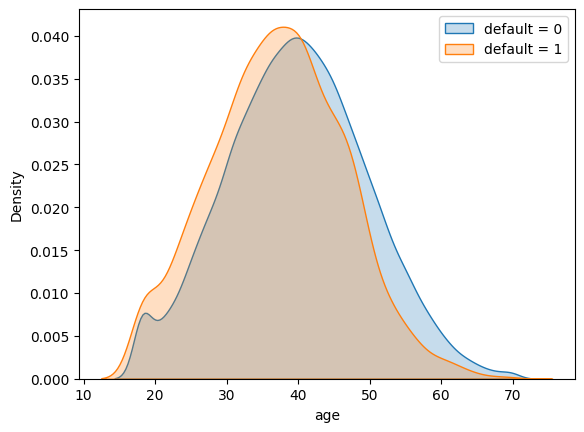

In [48]:
# Let's plot side by side kde plots for people who have deafulted and who haven't in age column
sns.kdeplot(df_train[df_train.default == 0].age, fill=True, label = 'default = 0')
sns.kdeplot(df_train[df_train.default == 1].age, fill=True, label = 'default = 1')
plt.legend()
plt.show()

We can have same plots for all other numeric columns too

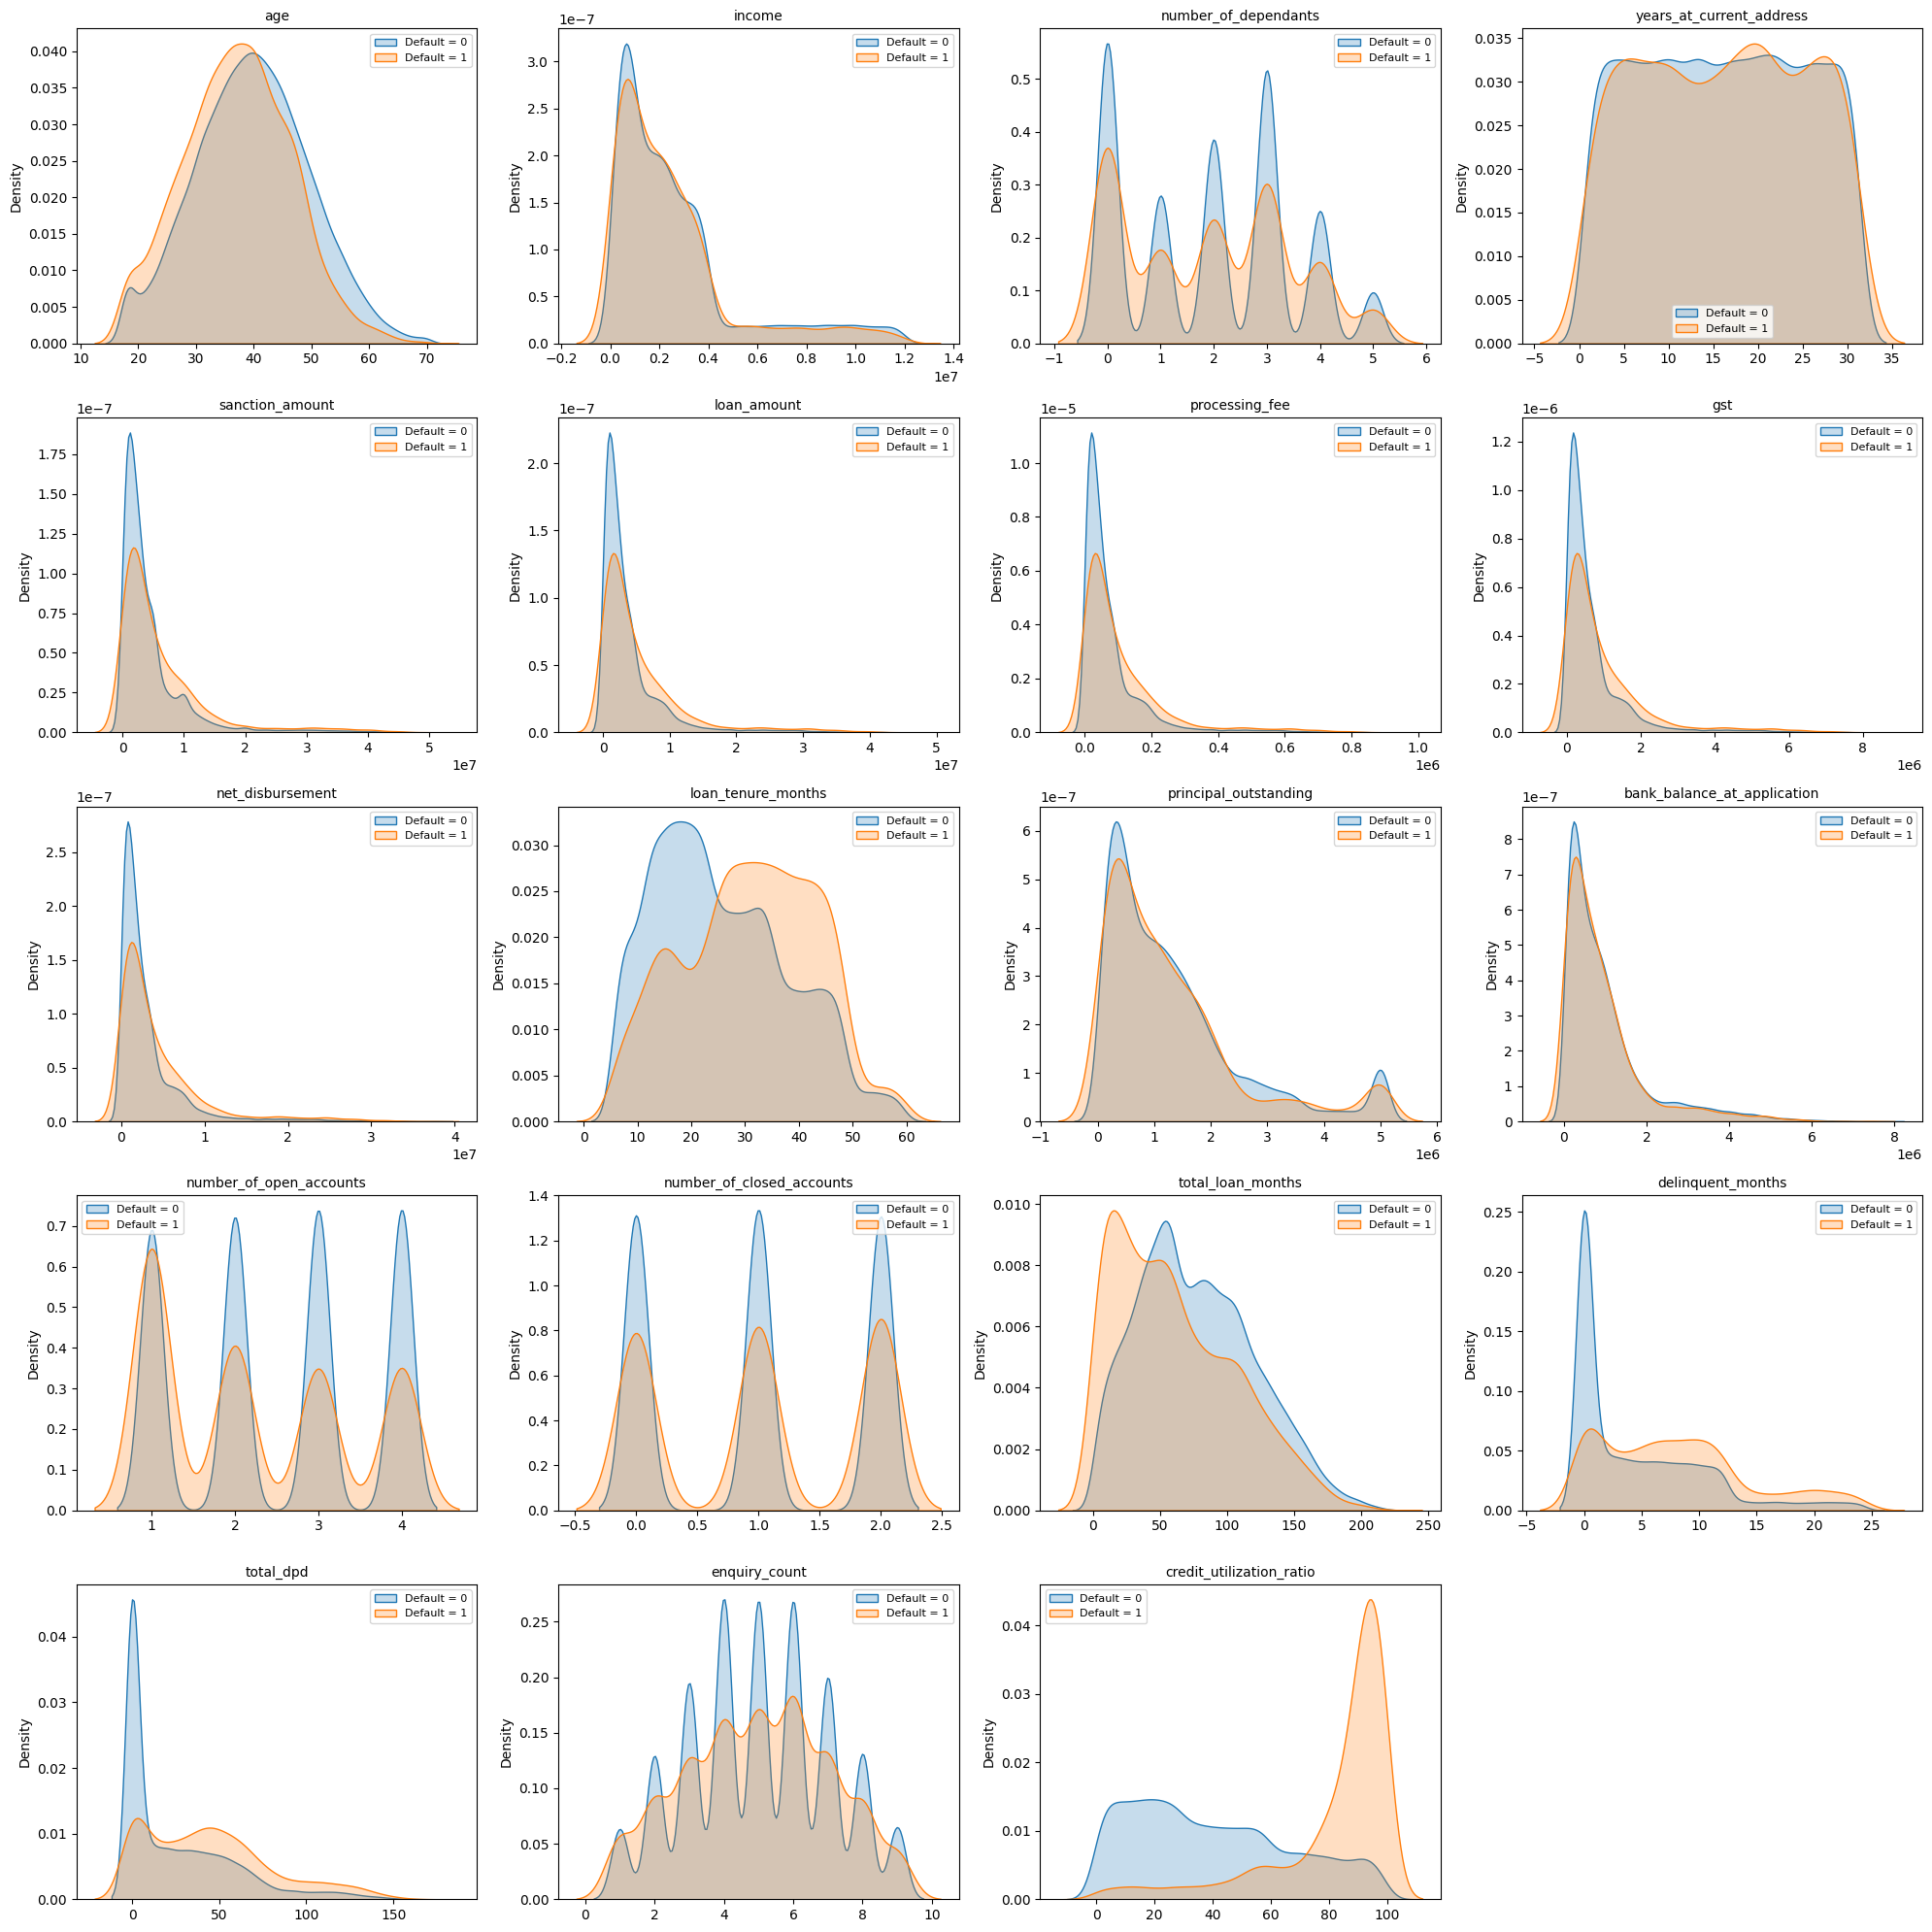

In [49]:
# Grid size
n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_columns):
    sns.kdeplot(data=df_train[df_train['default'] == 0],x=col,fill=True,label='Default = 0',ax=axes[i])
    sns.kdeplot(data=df_train[df_train['default'] == 1],x=col,fill=True,label='Default = 1',ax=axes[i])

    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('')

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Insights:
1. Here in age column indicates that people with lower age are more likely to get deafaulted.
2. In columns: loan_tenure_months, delinquent_months, total_dpd, credit_utilization_ratio, higher values indicate high likelyhood of becoming a default
3. In remaining columns distibution doesn't give any obvious insights.
4. Why loan amount and income didn't give any signs of being a strong predictor? May be when we combine these two and get loan to income ratio (LTI), that may have influence on the target variable, We will explore more later.

## Feature Engineering

In [50]:
# Loan to income ratio
df_train['loan_to_income'] = round(df_train['loan_amount']/df_train['income'],2)
df_test['loan_to_income'] = round(df_test['loan_amount']/df_test['income'],2)
df_train['loan_to_income'].describe()

count   37488.00
mean        1.56
std         0.97
min         0.30
25%         0.77
50%         1.16
75%         2.46
max         4.57
Name: loan_to_income, dtype: float64

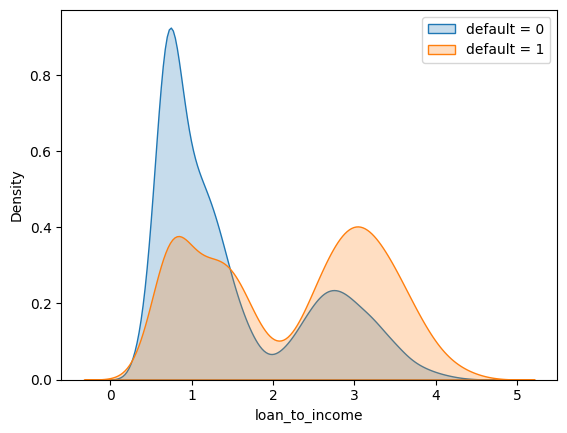

In [51]:
# Plotting KDE plot for LTI too
sns.kdeplot(df_train[df_train.default == 0].loan_to_income, fill=True, label = 'default = 0')
sns.kdeplot(df_train[df_train.default == 1].loan_to_income, fill=True, label = 'default = 1')
plt.legend()
plt.show()

So higher LTI ratio indicates higer chance of getting defaulted.

In [52]:
# Delinquency Ratio
df_train['delinquency_ratio'] = (df_train['delinquent_months'] * 100)/df_train['total_loan_months'].round(1)
df_test['delinquency_ratio'] = (df_test['delinquent_months'] * 100)/df_test['total_loan_months'].round(1)
df_train['delinquency_ratio'].describe()

count   37488.00
mean       10.33
std        17.30
min         0.00
25%         0.00
50%         3.68
75%        12.95
max       100.00
Name: delinquency_ratio, dtype: float64

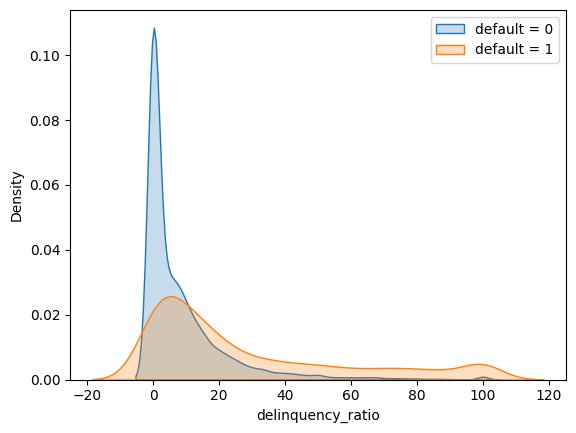

In [53]:
# KDE plot for deliquency ratio too
sns.kdeplot(df_train[df_train.default == 0].delinquency_ratio, fill=True, label = 'default = 0')
sns.kdeplot(df_train[df_train.default == 1].delinquency_ratio, fill=True, label = 'default = 1')
plt.legend()
plt.show()

So this means higher deliquency ratio idicates higher chances of becoming default.

In [54]:
# Average DPD Per deliquency
df_train['avg_dpd_per_delinquency'] = np.where(
    df_train['delinquent_months'] != 0,
    (df_train['total_dpd']/df_train['delinquent_months'].round(1)),
    0
)

df_test['avg_dpd_per_delinquency'] = np.where(
    df_test['delinquent_months'] != 0,
    (df_test['total_dpd']/df_test['delinquent_months'].round(1)),
    0
)

df_train['avg_dpd_per_delinquency'].describe()

count   37488.00
mean        3.28
std         2.91
min         0.00
25%         0.00
50%         4.33
75%         5.74
max        10.00
Name: avg_dpd_per_delinquency, dtype: float64

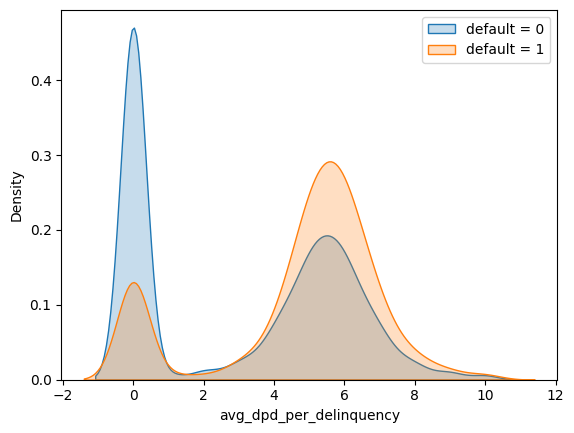

In [55]:
# KDE plot
sns.kdeplot(df_train[df_train.default == 0].avg_dpd_per_delinquency, fill=True, label = 'default = 0')
sns.kdeplot(df_train[df_train.default == 1].avg_dpd_per_delinquency, fill=True, label = 'default = 1')
plt.legend()
plt.show()

So this means higher avg_dpd_per_delinquency idicates higher chances of becoming default.

In [56]:
# Credit Utilization Per Income
df_train['credit_utilization_per_income'] = df_train['credit_utilization_ratio']/df_train['loan_to_income']
df_test['credit_utilization_per_income'] = df_test['credit_utilization_ratio']/df_test['loan_to_income']
df_train['credit_utilization_per_income'].describe()

count   37488.00
mean       40.24
std        38.51
min         0.00
25%        11.78
50%        27.59
75%        58.18
max       291.18
Name: credit_utilization_per_income, dtype: float64

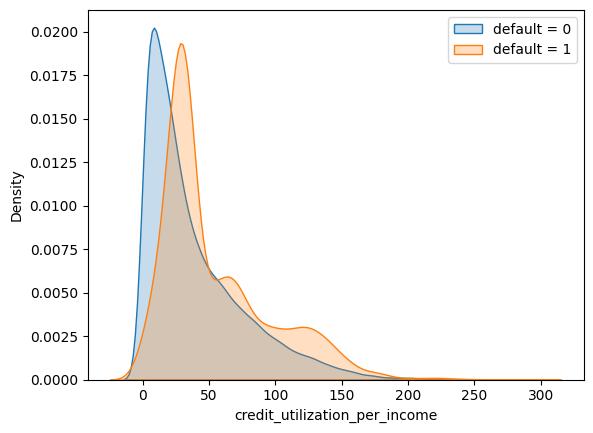

In [57]:
# KDE plot Credit Utilization Per Income
sns.kdeplot(df_train[df_train.default == 0].credit_utilization_per_income, fill=True, label = 'default = 0')
sns.kdeplot(df_train[df_train.default == 1].credit_utilization_per_income, fill=True, label = 'default = 1')
plt.legend()
plt.show()

The KDE plot indicates that borrowers with higher credit_utilization_per_income values are more likely to default, suggesting that this engineered feature has predictive value for credit risk modelling.

## Feature Selection

Numeric Columns:

In [58]:
df_train.shape

(37488, 37)

In [59]:
# Let's remove not nessessary columns
df_train = df_train.drop(['cust_id','loan_id'], axis = 1)
df_train.shape

(37488, 35)

In [60]:
# On test data also
df_test = df_test.drop(['cust_id','loan_id'], axis = 1)
df_test.shape

(12497, 35)

In [61]:
df_train.columns

Index(['age', 'gender', 'marital_status', 'employment_status', 'income',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'loan_amount', 'processing_fee', 'gst',
       'net_disbursement', 'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'disbursal_date', 'installment_start_dt',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'total_loan_months', 'delinquent_months', 'total_dpd', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'],
      dtype='object')

In [62]:
# Removing not useful columns according to our domain understanding, bussiness knowledge and common sense
# And some columns are feature engineered to some other column, so dropping the source columns too.
df_train = df_train.drop(['disbursal_date', 'installment_start_dt','loan_amount','income','total_loan_months','delinquent_months','total_dpd'], axis = 1)
df_test = df_test.drop(['disbursal_date', 'installment_start_dt','loan_amount','income','total_loan_months','delinquent_months','total_dpd'], axis = 1)

df_train.shape

(37488, 28)

### Handelling multicolinarity (using VIF)

For Calculating VIF first we have to scale all the numeric columns.

In [63]:
# Getting numeric column for scaling
cols_to_scale = ['age', 'number_of_dependants', 'years_at_current_address',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency','credit_utilization_per_income']

In [64]:
# Seperate feature and target variable for train dataset
X_train = df_train.drop(['default'],axis = 1)
y_train = df_train['default']

# Define Scaler 
scaler = MinMaxScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00,37488.00
mean,0.41,0.39,0.50,418876.24,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.10,0.33,0.14
std,0.19,0.31,0.30,169029.87,0.12,0.11,0.11,0.11,0.23,0.24,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29,0.13
min,0.00,0.00,0.00,110001.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,302001.00,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00,0.04
50%,0.40,0.40,0.50,400001.00,0.05,0.05,0.05,0.05,0.34,0.19,0.08,0.67,0.50,0.50,0.39,0.20,0.04,0.43,0.09
75%,0.54,0.60,0.77,560001.00,0.10,0.10,0.10,0.10,0.55,0.35,0.16,1.00,1.00,0.62,0.68,0.51,0.13,0.57,0.20
max,1.00,1.00,1.00,700001.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [65]:
# Now for test data
X_test = df_test.drop(['default'],axis = 1)
y_test = df_test['default']

# Scale it
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
count,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00,12497.00
mean,0.42,0.38,0.50,419759.82,0.09,0.08,0.08,0.08,0.38,0.26,0.12,0.50,0.50,0.50,0.44,0.29,0.11,0.33,0.14
std,0.19,0.31,0.30,168845.35,0.12,0.11,0.11,0.11,0.23,0.25,0.13,0.37,0.41,0.25,0.30,0.23,0.17,0.29,0.13
min,0.00,0.00,0.00,110001.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.29,0.00,0.23,302001.00,0.02,0.02,0.02,0.02,0.19,0.08,0.03,0.00,0.00,0.38,0.18,0.11,0.00,0.00,0.04
50%,0.42,0.40,0.50,411001.00,0.05,0.05,0.05,0.05,0.34,0.20,0.08,0.33,0.50,0.50,0.39,0.20,0.04,0.44,0.09
75%,0.54,0.60,0.77,560001.00,0.10,0.09,0.09,0.09,0.55,0.36,0.16,0.67,1.00,0.62,0.68,0.50,0.13,0.58,0.20
max,1.00,1.00,1.00,700001.00,0.98,0.96,0.96,0.96,1.00,1.00,0.94,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.96


In [66]:
# Function For calculating VIF
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [67]:
calculate_vif(X_train[cols_to_scale])

C:\Users\ANSHH\anaconda3\envs\ml_clean\lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Column,VIF
0,age,5.82
1,number_of_dependants,2.73
2,years_at_current_address,3.39
3,sanction_amount,101.15
4,processing_fee,inf
5,gst,inf
6,net_disbursement,inf
7,loan_tenure_months,6.33
8,principal_outstanding,16.64
9,bank_balance_at_application,10.15


Here we can see some columns have really high VIF, Some of them even have in infinity. So upon removing this columns one by one and recalculating VIF again on each step we found out below columns have very high multicolinarity and they should be dropped.

In [68]:
features_to_drop_vif = ['processing_fee','gst','net_disbursement','principal_outstanding','sanction_amount']

X_train = X_train.drop(features_to_drop_vif, axis = 1)
cols = X_train.select_dtypes(['int64','float64']).columns

vif_df = calculate_vif(X_train[cols])
vif_df

,Column,VIF
0,age,5.69
1,number_of_dependants,2.73
2,years_at_current_address,3.47
3,zipcode,5.69
4,loan_tenure_months,6.23
5,bank_balance_at_application,1.89
6,number_of_open_accounts,4.36
7,number_of_closed_accounts,2.39
8,enquiry_count,6.47
9,credit_utilization_ratio,10.13


Now the VIF is in good range, So we removed the multicolinarity from our train dataset.

In [69]:
# Listing selected numeric features due to VIF
selected_numeric_features_vif = vif_df.Column.values
selected_numeric_features_vif

array(['age', 'number_of_dependants', 'years_at_current_address',
       'zipcode', 'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts',
       'enquiry_count', 'credit_utilization_ratio', 'loan_to_income',
       'delinquency_ratio', 'avg_dpd_per_delinquency',
       'credit_utilization_per_income'], dtype=object)

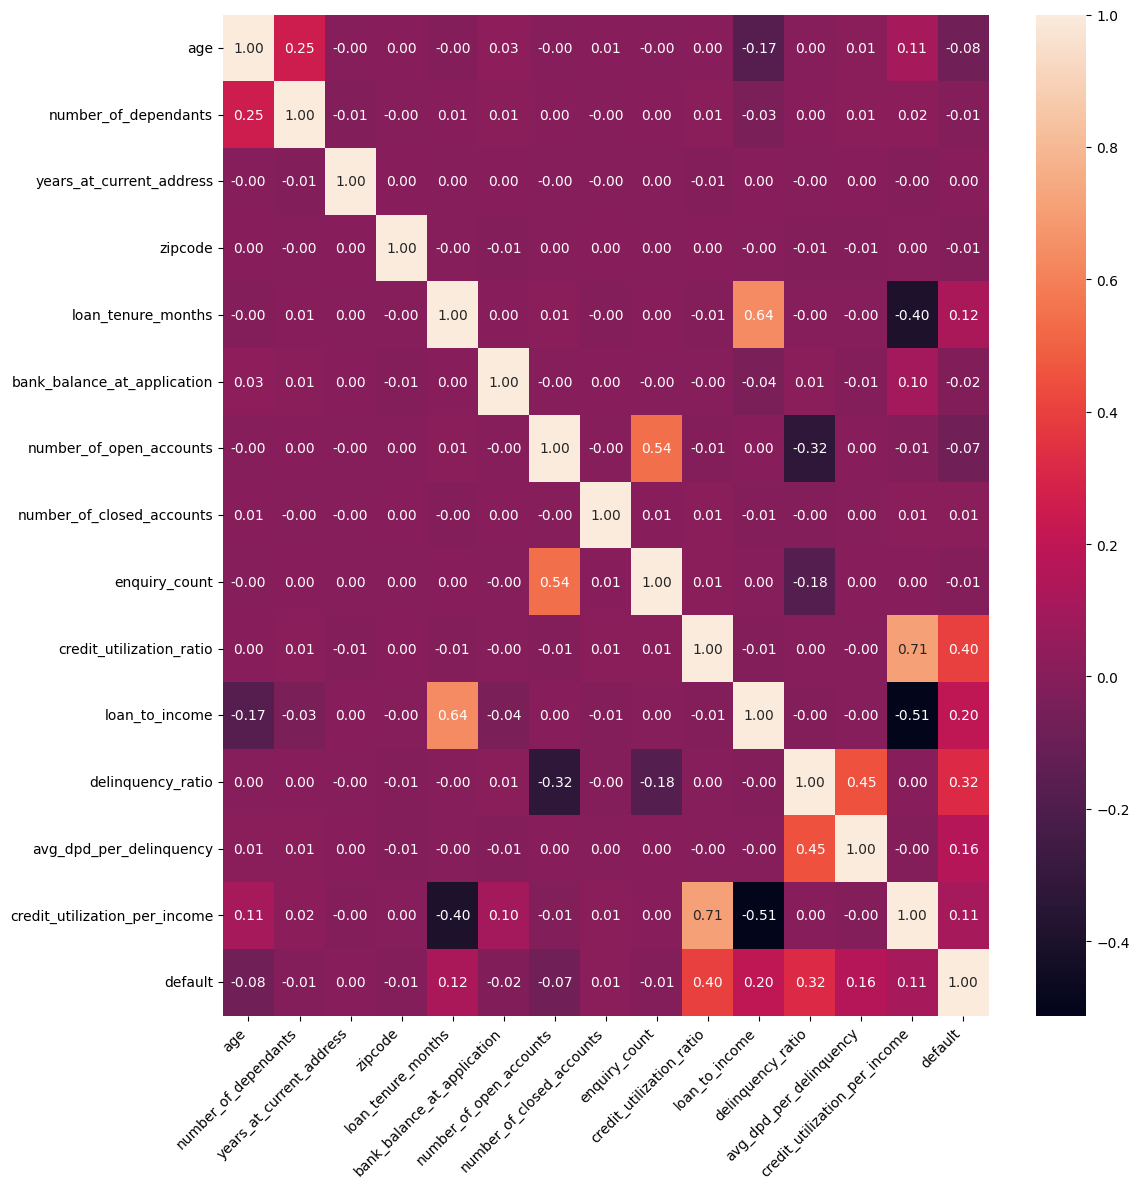

In [70]:
# Correaltion Matrix
plt.figure(figsize=(12,12))
cm = df_train[cols.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot = True, fmt = '0.2f')
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.tight_layout()
plt.show()

Categorical Columns:
- Now in Categorical Columns how to find predictive power of different columns? So here we use concept called Wight Of Evidence(WOE) and Information Value(IV)

#### WEIGHT OF EVIDENCE (WOE) & INFORMATION VALUE(IV):

* Information Value(IV) helps to quntify the predictive power of a feature(Primary Categorical Feature)
* **Formula:** IV = Sum(WOE * (Proportion of good - Proportion of bad))
* WOE = ln(Proportion of good/Proportion of bad)
* Based on the IV, we can determine whether to retain the feature or exclude it from the dataset.
* IV < 0.02 - Very Little predictive power
* 0.02 < IV < 0.1  - Weak predictive power
* 0.1 < IV < 0.3 - Medium
* 0.3 < IV < 0.5 - Strong
* IV >= 0.5 - Very Strong

Now Let's apply these concepts and calculate WOE and IV for our features.

In [71]:
X_train.head()

,age,gender,marital_status,employment_status,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode,...,loan_tenure_months,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
12746,0.79,M,Married,Self-Employed,0.60,Owned,0.97,Hyderabad,Telangana,500001,...,0.42,0.61,1.00,1.00,0.38,0.36,0.41,0.13,0.59,0.06
32495,0.50,F,Single,Salaried,0.00,Owned,0.87,Mumbai,Maharashtra,400001,...,0.83,0.03,0.67,0.50,0.50,0.05,0.31,0.06,0.62,0.01
43675,0.38,M,Single,Salaried,0.00,Mortgage,0.83,Chennai,Tamil Nadu,600001,...,0.49,0.17,0.00,0.50,0.38,0.00,0.76,0.22,0.56,0.00
9040,0.46,M,Married,Salaried,0.40,Mortgage,0.97,Bangalore,Karnataka,560001,...,0.64,0.08,0.67,0.00,0.88,0.88,0.19,0.00,0.00,0.26
13077,0.77,M,Married,Self-Employed,0.80,Owned,0.93,Pune,Maharashtra,411001,...,0.17,0.07,0.00,1.00,0.00,0.72,0.05,0.00,0.00,0.49


In [72]:
# Creating function to calculate woe and iv

def calculate_woe_iv(df, feature, target):
    grouped = df.groupby(feature)[target].agg(['count','sum']) # First group them by given feature
    grouped = grouped.rename(columns = {'count' : 'total', 'sum' : 'good'}) # Changing column name for better understanding
    
    grouped['bad'] = grouped['total'] - grouped['good'] # Calculating bad count
    
    total_good = grouped['good'].sum() # Totals for both to calculate pct
    total_bad = grouped['bad'].sum()

    grouped['good_pct'] = grouped['good']/total_good # Percentages/Proportions
    grouped['bad_pct'] = grouped['bad']/total_bad

    grouped['woe'] =  np.log(grouped['good_pct']/grouped['bad_pct']) # Calulated Just as above formula
    grouped['iv'] = grouped['woe'] * (grouped['good_pct'] - grouped['bad_pct'])

    grouped['woe'] = grouped['woe'].replace([np.inf, -np.inf], 0) # Replacing inf with zero
    grouped['iv'] = grouped['iv'].replace([np.inf, -np.inf], 0)
    

    total_iv = grouped['iv'].sum() # Total Information Value
    
    return grouped, total_iv

In [73]:
# Using above func on our dataframe to calculate IV for each feature

iv_values = {} # Dict to store IV Values

for feature in X_train.columns:
    if X_train[feature].dtype == 'object': # For Categorical Columns
        _, iv = calculate_woe_iv(pd.concat([X_train, y_train], axis = 1), feature, 'default')
    else:
        X_binned = pd.cut(X_train[feature], bins = 10, labels= False)  # For Numerical Columns
        _, iv = calculate_woe_iv(pd.concat([X_binned, y_train], axis = 1), feature, 'default')
    iv_values[feature] = iv

        
iv_values

{'age': 0.0890689462679479,
 'gender': 0.00047449502170914947,
 'marital_status': 0.001129766845390142,
 'employment_status': 0.003953046301722585,
 'number_of_dependants': 0.0019380899135053508,
 'residence_type': 0.246745268718145,
 'years_at_current_address': 0.0020800513608156363,
 'city': 0.0019059578709781529,
 'state': 0.0019005589806779287,
 'zipcode': 0.0016677413243392572,
 'loan_purpose': 0.3691197842282755,
 'loan_type': 0.16319324904149224,
 'loan_tenure_months': 0.21893515090196278,
 'bank_balance_at_application': 0.0063187993277516365,
 'number_of_open_accounts': 0.08463134083005877,
 'number_of_closed_accounts': 0.0011964272592421567,
 'enquiry_count': 0.007864214085342608,
 'credit_utilization_ratio': 2.352965568168245,
 'loan_to_income': 0.476415456948364,
 'delinquency_ratio': 0.716576108689321,
 'avg_dpd_per_delinquency': 0.40176623566177694,
 'credit_utilization_per_income': 0.19552785320955066}

To calulate IV of Numerical Columns we have to bin them first using pd.cut, then it behaves just like categorical column.

In [74]:
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x)) # Temp changing the decimal precision to 3 

iv_df = pd.DataFrame(list(iv_values.items()), columns = ['Feature','IV']) # Creating Data frame for iv values
iv_df = iv_df.sort_values(by = 'IV', ascending=False) # Sorting in descending order
iv_df

,Feature,IV
17,credit_utilization_ratio,2.353
19,delinquency_ratio,0.717
18,loan_to_income,0.476
20,avg_dpd_per_delinquency,0.402
10,loan_purpose,0.369
5,residence_type,0.247
12,loan_tenure_months,0.219
21,credit_utilization_per_income,0.196
11,loan_type,0.163
0,age,0.089


Selecting the features with Information Values > 0.02 

In [75]:
selected_feature_iv = [feature for feature, iv in iv_values.items() if iv > 0.02]
selected_feature_iv

['age',
 'residence_type',
 'loan_purpose',
 'loan_type',
 'loan_tenure_months',
 'number_of_open_accounts',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency',
 'credit_utilization_per_income']

In [77]:
# Creating new reduced dataframes for this final selected features
X_train_reduced = X_train[selected_feature_iv]
X_test_reduced = X_test[selected_feature_iv]

X_train_reduced.head()

,age,residence_type,loan_purpose,loan_type,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income
12746,0.788,Owned,Home,Secured,0.415,1.000,0.364,0.415,0.132,0.590,0.060
32495,0.500,Owned,Education,Secured,0.830,0.667,0.051,0.307,0.062,0.620,0.011
43675,0.385,Mortgage,Home,Secured,0.491,0.000,0.000,0.759,0.222,0.558,0.000
9040,0.462,Mortgage,Education,Secured,0.642,0.667,0.879,0.194,0.000,0.000,0.264
13077,0.769,Owned,Personal,Unsecured,0.170,0.000,0.717,0.047,0.000,0.000,0.488


### Feature Encoding

In [78]:
# Now let's encode categorical values using one hot encoding
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True) 
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True) 


In [80]:
X_train_encoded.head()

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
12746,0.788,0.415,1.000,0.364,0.415,0.132,0.590,0.060,True,False,False,True,False,False
32495,0.500,0.830,0.667,0.051,0.307,0.062,0.620,0.011,True,False,True,False,False,False
43675,0.385,0.491,0.000,0.000,0.759,0.222,0.558,0.000,False,False,False,True,False,False
9040,0.462,0.642,0.667,0.879,0.194,0.000,0.000,0.264,False,False,True,False,False,False
13077,0.769,0.170,0.000,0.717,0.047,0.000,0.000,0.488,True,False,False,False,True,True


### Model Training

#### Attempt 1

1. Logistic Regression, RandomForest, & XGB
2. No handelling of Class imbalance

In [81]:
# Logistic Regression

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.73      0.78      1074

    accuracy                           0.97     12497
   macro avg       0.91      0.86      0.88     12497
weighted avg       0.96      0.97      0.96     12497



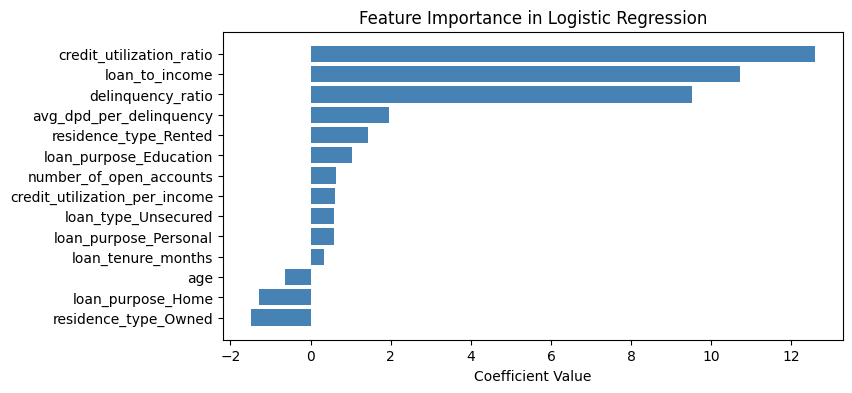

In [82]:
feature_importance = model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [83]:
# Random Forest

model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.86      0.71      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [84]:
# XGBoost 

model = XGBClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.75      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.97      0.96     12497



Since there is not much difference between XGB and Logistic, we will choose LogisticRegression as a candidate for our RandomizedSearchCV candidate it has a better interpretation.

#### RandomizedSearch CV for Attempt 1: Logistic Regression

In [85]:
param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'liblinear', 'C': 1438.44988828766}
Best Score: 0.757834586669046
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



#### RandomizedSearch CV for Attempt 1: XGBoost

In [86]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.7, 'scale_pos_weight': 2, 'reg_lambda': 10.0, 'reg_alpha': 0.01, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best Score: 0.7890104228925917
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.77      0.84      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.91      0.89     12497
weighted avg       0.97      0.96      0.97     12497



In our 1st attempt(With class imbalance) all 3 models and randomsearch are giving simillar bad recall score, And we want higher recall for class 1 at least > 0.90.

#### Attempt 2

1. Logistic Regression & XGB
2. Handle Class Imbalance Using Under Sampling

In [87]:
# Creating undersampler
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train_encoded, y_train)
y_train_rus.value_counts()

default
0    3223
1    3223
Name: count, dtype: int64

In [88]:
# Logistic Regression

model = LogisticRegression()
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95     11423
           1       0.51      0.96      0.67      1074

    accuracy                           0.92     12497
   macro avg       0.75      0.93      0.81     12497
weighted avg       0.95      0.92      0.93     12497



In [89]:
# XGBoost 

model = XGBClassifier(**random_search.best_params_)
model.fit(X_train_rus, y_train_rus)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.92      0.95     11423
           1       0.52      0.98      0.68      1074

    accuracy                           0.92     12497
   macro avg       0.76      0.95      0.82     12497
weighted avg       0.96      0.92      0.93     12497



### Attempt 3

1. Logistic Regression
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [90]:
smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34209
1    34209
Name: count, dtype: int64

In [91]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [92]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-07-10 13:27:23,124] A new study created in memory with name: no-name-373f5f21-2448-4275-9f95-2a354de854fc
C:\Users\ANSHH\anaconda3\envs\ml_clean\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[I 2026-07-10 13:27:28,475] Trial 0 finished with value: 0.9293987774924274 and parameters: {'C': 0.2566287381313323, 'solver': 'newton-cg', 'tol': 0.012663237319422118, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.9293987774924274.
[I 2026-07-10 13:27:30,631] Trial 1 finished with value: 0.9285020210613778 and parameters: {'C': 0.008999611162027533, 'solver': 'newton-cg', 'tol': 0.0005747077317039361, 'class_weight': None}. Best is trial 0 with value: 0.9293987774924274.
[I 2026-07-10 13:27:33,760] Trial 2 finished with value: 0.9398231438415742 and parameters: {'C': 0.06797021805834223, 'solver': '

In [93]:
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9461975043615873
  Params: 
    C: 8.213730965815728
    solver: newton-cg
    tol: 1.5602767168495035e-05
    class_weight: None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.95      0.71      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



### Attempt 4

1. XGBoost
1. Handle Class Imbalance Using SMOTE Tomek
1. Parameter tunning using optuna

In [94]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-07-10 13:28:48,700] A new study created in memory with name: no-name-08412956-ce65-43d7-abd5-73862080cf13
[I 2026-07-10 13:29:01,922] Trial 0 finished with value: 0.7554934642711593 and parameters: {'lambda': 0.09604282116259537, 'alpha': 0.05881312618431942, 'subsample': 0.6856334512583788, 'colsample_bytree': 0.6725332411259711, 'max_depth': 10, 'eta': 0.06741105887535351, 'gamma': 2.3686069192300065, 'scale_pos_weight': 4.314011871578193, 'min_child_weight': 10, 'max_delta_step': 0}. Best is trial 0 with value: 0.7554934642711593.
[I 2026-07-10 13:29:05,426] Trial 1 finished with value: 0.7130542620218095 and parameters: {'lambda': 0.09224916225114461, 'alpha': 0.012450370619379385, 'subsample': 0.46531588361919507, 'colsample_bytree': 0.5195933780110438, 'max_depth': 3, 'eta': 0.14305831510123249, 'gamma': 0.3835143813011177, 'scale_pos_weight': 7.507375191585006, 'min_child_weight': 3, 'max_delta_step': 4}. Best is trial 0 with value: 0.7554934642711593.
[I 2026-07-10 13:2

In [95]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.7860222401398104
  Params: 
    lambda: 0.008086264981546444
    alpha: 0.5690741753420862
    subsample: 0.8237978229228758
    colsample_bytree: 0.6937595546765654
    max_depth: 10
    eta: 0.20196786244423423
    gamma: 0.8846574373052976
    scale_pos_weight: 1.0528440612896772
    min_child_weight: 4
    max_delta_step: 5
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11423
           1       0.74      0.82      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.86      0.90      0.88     12497
weighted avg       0.96      0.96      0.96     12497



So from optuna optimization we can see that the Logistic Regression Model is performing better than the XGBoost model, So our best final model is best_model_logistic.

### Model Evaluation : ROC/AUC

In [96]:
y_pred = best_model_logistic.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.56      0.95      0.71      1074

    accuracy                           0.93     12497
   macro avg       0.78      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



Plotting ROC/AUC Curve for this model now.

In [97]:
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.        , 0.        , 0.        , 0.00008754, 0.00008754]),
 array([0.        , 0.0009311 , 0.15549348, 0.15549348, 0.16759777]),
 array([       inf, 1.        , 0.99954472, 0.99954011, 0.9994525 ]))

In [98]:
# Calculating Area
area = auc(fpr, tpr)
area

0.9837803960156833

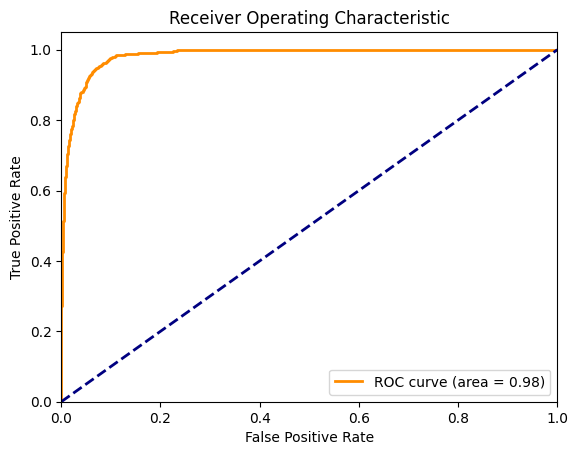

In [100]:
# Plotting the curve now
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

So It's covering 98% of area with True Positive which is really good performance.

### Model Evaluation : Rankordering, KS statistic, Gini coeff

- Rank Ordering and KS Statistics are crucial  metrics used to evaluate performance of real world credit risk models.
- The process involvs sorting borrowers by predicting default probabilities and observing actual defaults in grouped segments like deciles.
- The KS statistic measures the maximum difference in cumilitive distributions of defaulters versus non-defaulters, indicating model discrimination quality.
- A high KS value suggests strong model performance, with a clear seperation between high risk and low-risk borrowers. KS value of more than 40 is considered a good model.

Traditional classification metrics measure prediction performance, whereas KS Statistic and Rank Ordering evaluate the model's ability to separate and rank borrowers by default risk, making them essential business metrics in credit risk modelling.

In [101]:
# Getting the predictions from our best model for default case
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]

# Let's create data frame of it now
df_eval = pd.DataFrame({
    'Default Truth' : y_test,
    'Default Probability' : probabilities
})
df_eval.head()

,Default Truth,Default Probability
19205,0,0.513
15514,0,0.000
30367,0,0.005
35347,0,0.006
41814,1,0.913


In [102]:
# Create Decile 
df_eval['Decile'] = pd.qcut(df_eval['Default Probability'], q=10, labels=False, duplicates='drop')
df_eval.head()

,Default Truth,Default Probability,Decile
19205,0,0.513,8
15514,0,0.000,2
30367,0,0.005,6
35347,0,0.006,6
41814,1,0.913,9


In [103]:
df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({
    'Minimum Probability' : x['Default Probability'].min(),
    'Maximum Probability' : x['Default Probability'].max(),
    'Events' : x['Default Truth'].sum(),
    'Non-events' : x['Default Truth'].count() - x['Default Truth'].sum(),
}))

df_decile = df_decile.reset_index()
df_decile

C:\Users\ANSHH\AppData\Local\Temp\ipykernel_30264\430775037.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_decile = df_eval.groupby('Decile').apply(lambda x: pd.Series({


,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,0,0.000,0.000,0.000,1250.000
1,1,0.000,0.000,0.000,1250.000
2,2,0.000,0.000,0.000,1249.000
3,3,0.000,0.000,0.000,1250.000
4,4,0.000,0.001,0.000,1250.000
5,5,0.001,0.004,0.000,1249.000
6,6,0.004,0.026,2.000,1248.000
7,7,0.026,0.208,13.000,1236.000
8,8,0.208,0.819,158.000,1092.000
9,9,0.820,1.000,901.000,349.000


In [104]:
# Let's order this now
df_decile = df_decile.sort_values(by='Decile', ascending=False).reset_index(drop=True)
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events
0,9,0.820,1.000,901.000,349.000
1,8,0.208,0.819,158.000,1092.000
2,7,0.026,0.208,13.000,1236.000
3,6,0.004,0.026,2.000,1248.000
4,5,0.001,0.004,0.000,1249.000
5,4,0.000,0.001,0.000,1250.000
6,3,0.000,0.000,0.000,1250.000
7,2,0.000,0.000,0.000,1249.000
8,1,0.000,0.000,0.000,1250.000
9,0,0.000,0.000,0.000,1250.000


In [105]:
# Finding Event and Non Event Rate now
df_decile['Event Rate'] = (df_decile['Events']*100)/(df_decile['Events'] + df_decile['Non-events'])
df_decile['Non-event Rate'] = (df_decile['Non-events']*100)/(df_decile['Events'] + df_decile['Non-events'])

df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate
0,9,0.820,1.000,901.000,349.000,72.080,27.920
1,8,0.208,0.819,158.000,1092.000,12.640,87.360
2,7,0.026,0.208,13.000,1236.000,1.041,98.959
3,6,0.004,0.026,2.000,1248.000,0.160,99.840
4,5,0.001,0.004,0.000,1249.000,0.000,100.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000
6,3,0.000,0.000,0.000,1250.000,0.000,100.000
7,2,0.000,0.000,0.000,1249.000,0.000,100.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000


In [106]:
# Finding Cumilitive Events and Cumilitve Non Events
df_decile['Cum Events'] = df_decile['Events'].cumsum()
df_decile['Cum Non-events'] = df_decile['Non-events'].cumsum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events
0,9,0.820,1.000,901.000,349.000,72.080,27.920,901.000,349.000
1,8,0.208,0.819,158.000,1092.000,12.640,87.360,1059.000,1441.000
2,7,0.026,0.208,13.000,1236.000,1.041,98.959,1072.000,2677.000
3,6,0.004,0.026,2.000,1248.000,0.160,99.840,1074.000,3925.000
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5174.000
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000


In [107]:
# Finding Cumilitive Rates
df_decile['Cum Event Rate'] = (df_decile['Cum Events']*100)/df_decile['Events'].sum()
df_decile['Cum Non-event Rate'] = (df_decile['Cum Non-events']*100)/df_decile['Non-events'].sum()
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate
0,9,0.820,1.000,901.000,349.000,72.080,27.920,901.000,349.000,83.892,3.055
1,8,0.208,0.819,158.000,1092.000,12.640,87.360,1059.000,1441.000,98.603,12.615
2,7,0.026,0.208,13.000,1236.000,1.041,98.959,1072.000,2677.000,99.814,23.435
3,6,0.004,0.026,2.000,1248.000,0.160,99.840,1074.000,3925.000,100.000,34.361
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5174.000,100.000,45.295
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000,100.000,56.237
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000,100.000,67.180
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000


In [108]:
# Finaly the KS Values
df_decile['KS'] = abs(df_decile['Cum Event Rate'] - df_decile['Cum Non-event Rate'])
df_decile

,Decile,Minimum Probability,Maximum Probability,Events,Non-events,Event Rate,Non-event Rate,Cum Events,Cum Non-events,Cum Event Rate,Cum Non-event Rate,KS
0,9,0.820,1.000,901.000,349.000,72.080,27.920,901.000,349.000,83.892,3.055,80.837
1,8,0.208,0.819,158.000,1092.000,12.640,87.360,1059.000,1441.000,98.603,12.615,85.988
2,7,0.026,0.208,13.000,1236.000,1.041,98.959,1072.000,2677.000,99.814,23.435,76.379
3,6,0.004,0.026,2.000,1248.000,0.160,99.840,1074.000,3925.000,100.000,34.361,65.639
4,5,0.001,0.004,0.000,1249.000,0.000,100.000,1074.000,5174.000,100.000,45.295,54.705
5,4,0.000,0.001,0.000,1250.000,0.000,100.000,1074.000,6424.000,100.000,56.237,43.763
6,3,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,7674.000,100.000,67.180,32.820
7,2,0.000,0.000,0.000,1249.000,0.000,100.000,1074.000,8923.000,100.000,78.114,21.886
8,1,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,10173.000,100.000,89.057,10.943
9,0,0.000,0.000,0.000,1250.000,0.000,100.000,1074.000,11423.000,100.000,100.000,0.000


To assess whether rank ordering is followed, we should look at whether higher deciles (those with higher predicted probabilities) have higher event rates compared to lower deciles. Rank ordering means that as you move from the top decile to the bottom decile, the event rate should generally decrease.

Non-Events - termed as good (customers) who do not default. Events - termed as bad (customers) who default.

Events and Non-Events terms are interchanged based on usecase to usecase.

eg: for marketing usecase, which customer to reach out (who will take loan based on offers) will be events - here it will termed as good, and the customers who will not take loans will be non-events (bad).

**Insights from the Decile Table**

1. Top Deciles

* The first decile (Decile 9) has a high event rate of 72.00% and a non-event rate of 28.00%. This indicates that the model is highly confident in predicting events in this decile.
* The second decile (Decile 8) also shows a significant event rate of 12.72%, with a cumulative event rate reaching 98.6%.

2. Middle Deciles:

* Deciles 7 and 6 show a significant drop in event rates

3. Lower Deciles:

* Deciles 5 to 0 show zero events, with all predictions being non-events. These deciles collectively have a non-event rate of 100%.

4. KS Statistic:

* The KS statistic, which is the maximum difference between cumulative event rates and cumulative non-event rates, is highest at Decile 8 with a value of 85.98%. This suggests that the model performs best at distinguishing between events and non-events up to this decile.

* The KS value gradually decreases in the following deciles, indicating a decrease in model performance for distinguishing between events and non-events.

**KS Value**

The highest KS value is 85.98%, found at Decile 8. This indicates that the model's performance in distinguishing between events and non-events is most significant at this decile. (If KS is in top 3 decile and score above 40, it is considered a good predictive model.)

In [109]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9837803960156833
Gini Coefficient: 0.9675607920313667


AUC of 0.98: The model is very good at distinguishing between events and non-events.

Gini coefficient of 0.96: This further confirms that the model is highly effective in its predictions, with almost perfect rank ordering capability.

The Gini coefficient ranges from -1 to 1, where a value closer to 1 signifies a perfect model, 0 indicates a model with no discriminative power, and -1 signifies a perfectly incorrect model.

#### Finalize The Model and Visualize Feature Importance

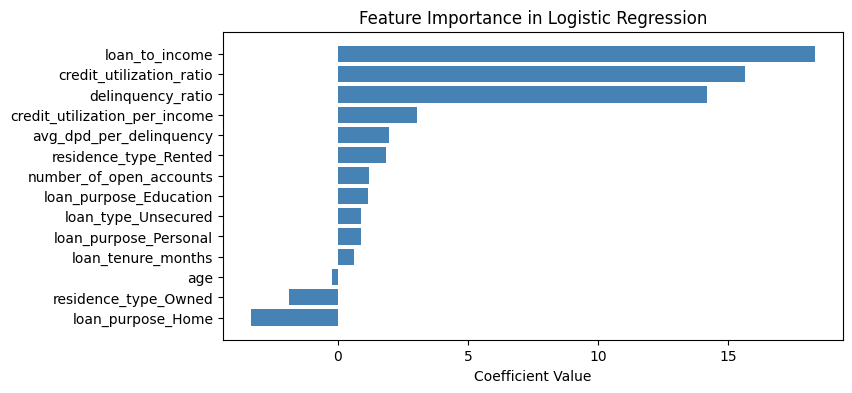

In [110]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

### Save the model

In [112]:
X_test_encoded.head(2)

,age,loan_tenure_months,number_of_open_accounts,credit_utilization_ratio,loan_to_income,delinquency_ratio,avg_dpd_per_delinquency,credit_utilization_per_income,residence_type_Owned,residence_type_Rented,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,loan_type_Unsecured
19205,0.346,0.755,0.333,0.990,0.550,0.000,0.000,0.127,True,False,False,True,False,False
15514,0.481,0.226,1.000,0.323,0.220,0.000,0.000,0.089,True,False,True,False,False,False


In [113]:
X_test_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income',
       'residence_type_Owned', 'residence_type_Rented',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
       'loan_type_Unsecured'],
      dtype='object')

In [114]:
cols_to_scale

['age',
 'number_of_dependants',
 'years_at_current_address',
 'sanction_amount',
 'processing_fee',
 'gst',
 'net_disbursement',
 'loan_tenure_months',
 'principal_outstanding',
 'bank_balance_at_application',
 'number_of_open_accounts',
 'number_of_closed_accounts',
 'enquiry_count',
 'credit_utilization_ratio',
 'loan_to_income',
 'delinquency_ratio',
 'avg_dpd_per_delinquency',
 'credit_utilization_per_income']

In [115]:
X_train_encoded.columns

Index(['age', 'loan_tenure_months', 'number_of_open_accounts',
       'credit_utilization_ratio', 'loan_to_income', 'delinquency_ratio',
       'avg_dpd_per_delinquency', 'credit_utilization_per_income',
       'residence_type_Owned', 'residence_type_Rented',
       'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Personal',
       'loan_type_Unsecured'],
      dtype='object')

In [117]:
from joblib import dump

model_data = {
    'model' : final_model,
    'features' : X_train_encoded.columns,
    'scaler' : scaler,
    'cols_to_scale' : cols_to_scale
}

# Dumping the model
dump(model_data, '../app/artifacts/model_data.joblib')

['../app/artifacts/model_data.joblib']

In [118]:
final_model.coef_, final_model.intercept_

(array([[-0.2008491 ,  0.62949139,  1.20946577, 15.6408838 , 18.31503132,
         14.17413049,  1.97524919,  3.04248694, -1.86331801,  1.86978425,
          1.17584046, -3.32305742,  0.88042311,  0.88042311]]),
 array([-21.51864496]))

Now we will use this model in streamlit application.